# run on astro3

In [1]:
import sys, pdb, glob, numpy as np, astropy
import pylab as pl
from importlib import reload
from astropy import constants as cons, units as un
from matplotlib import ticker
sys.path.append('../pysrc/')

In [2]:
from workdirs import *
import FIRE_files as ff
ff.pyobjDir = basedir+'pyobj/profilers/'
import my_utils as u


Behroozi+18 not loaded


In [3]:
#f = np.load('/Users/jonathanstern/Dropbox/jonathanmain/CGM/rapidCoolingCGM/pyobj/no_yt_analysis/profiler_m12i_md_7100_z0.1377.npz')

In [14]:
simnames = ('m11d','m11h','m11i','m12b','m12f','m12i','m12r','m12w')
iSnapshots = np.arange(500,600,30)
ions = (None,None),('O',5),('Si',2),('Si',1)

In [ ]:
spin_total_mag = np.zeros((len(simnames),len(iSnapshots),len(ions)))
spin_total_z   = np.zeros((len(simnames),len(iSnapshots),len(ions)))
mvirs = np.zeros((len(simnames),len(iSnapshots)))
for isim,simname in enumerate(simnames):
    print('==========',simname,'============')
    _simdir = simdir + 'metal_diffusion/%s_r7100/'%simname
    for iiSnapshot,iSnapshot in enumerate(iSnapshots[:]):
        sim = ff.Snapshot_meta(simname,'md','7100',_simdir+'output/',
                               '/jonathan_storage/sternjon/%s.dat'%simname,
                               iSnapshot=iSnapshot,snapshot_in_directory=(simname[2]=='2'))
        snapshot = ff.Snapshot(sim,loadAll=False)
        profiler = ff.Snapshot_profiler(snapshot)    
        vvir = ((cons.G*profiler.mvir*un.Msun/(profiler.rvir*un.kpc))**0.5).to('km/s').value
        for iIon,(element,ionizationLevel) in enumerate(ions):
            if element==None:
                weight='MW'
                suffix = ''
            else:
                weight='ion'
                suffix = 'ion_%s%d'%(element,ionizationLevel+1)
            jvecProfile = np.array(profiler.jvec_Profile(weight,element=element,ionizationLevel=ionizationLevel))
            jzProfile = profiler.jzProfile(weight,element=element,ionizationLevel=ionizationLevel)
            inds = (profiler.rs_midbins() > 0.1*profiler.rvir) & (profiler.rs_midbins() < profiler.rvir)        
            masses = profiler.get_saved('j_vec_weight'+suffix)
            j_total = (jvecProfile*masses)[:,inds].sum(axis=1) / masses[inds].sum()
            jz_total = (jzProfile*masses)[inds].sum()  / masses[inds].sum()
            spin_total_mag[isim][iiSnapshot][iIon] = (j_total**2).sum()**0.5 / (2**0.5 * vvir * profiler.rvir )
            spin_total_z[isim][iiSnapshot][iIon]   = jz_total / (2**0.5 * vvir * profiler.rvir )
        mvirs[isim][iiSnapshot] = profiler.mvir
        profiler.tofile()
np.savez('spin_measurements.npz',mvir=mvirs,spin=spin_total_mag,spin_z=spin_total_z)

# move to local computer:
## cpfromastro3 gizmo_analysis/ipynb/spin_measurements.npz


In [11]:
FIRE = np.load('/Users/jonathanstern/Dropbox/github_repositories/gizmo_analysis/pyobjs/spin_measurements.npz')
TNG = np.load('/Users/jonathanstern/Dropbox/github_repositories/gizmo_analysis/pyobjs/TNG50_m_virs_lambda_lambda_Z.npy')

In [12]:
np.savez('../pyobjs/FIRE_spins.npz',mvirs=FIRE['mvir'].mean(axis=1),spins=FIRE['spin'].mean(axis=1),spin_zs=FIRE['spin_z'].mean(axis=1))
np.savez('../pyobjs/TNG50_spins.npz',mvirs=TNG[0],spins=TNG[1],spin_zs=TNG[2])

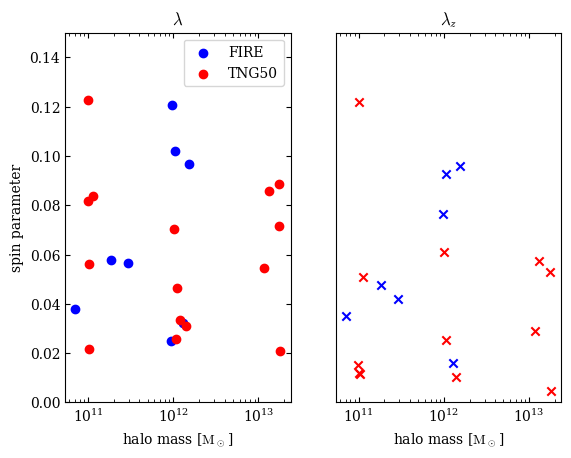

In [13]:
pl.figure()
for iPanel in range(2):
    ax = pl.subplot(1,2,1+iPanel)
    if iPanel==0:
        pl.scatter(FIRE['mvir'].mean(axis=1),FIRE['spin'].mean(axis=1),c='b',marker='o',label='FIRE')
        pl.scatter(TNG[0],TNG[1],c='r',marker='o',label='TNG50')
        pl.title(r'$\lambda$')
        pl.legend()
        pl.ylabel('spin parameter')
    if iPanel==1:
        pl.scatter(FIRE['mvir'].mean(axis=1),FIRE['spin_z'].mean(axis=1),c='b',marker='x')
        pl.scatter(TNG[0],TNG[2],c='r',marker='x')
        ax.yaxis.set_major_locator(ticker.NullLocator())
        pl.title(r'$\lambda_z$')
    pl.semilogx()
    pl.xlabel(r'halo mass [${\rm M}_\odot$]')
    pl.ylim(0,0.15)
pl.savefig('../figures/simulated_spins.png')
    
